In [2]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

#For Preprocessing and Evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,f1_score

In [4]:
##Data preprocessing

#Load dataset
df=pd.read_csv("survey lung cancer.csv")
df.reset_index(inplace=True)
print(df.head(5))

#--Dataset overview
print(df.info())
print(df.nunique())

#--Remove unnecessary columns that doesnt helps to train the model
df=df.drop('index',axis=1)
#--Remove duplicates(if any)
df=df.drop_duplicates()

#Label encoding
le1=LabelEncoder()
le2=LabelEncoder()
df['LUNG_CANCER']=le1.fit_transform(df['LUNG_CANCER'])
df['GENDER']=le2.fit_transform(df['GENDER'])
print("After lebel encoding:\n")
print(df.head())

   index GENDER  AGE  SMOKING  ...  SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN  LUNG_CANCER
0      0      M   69        1  ...                    2                      2           2          YES
1      1      M   74        2  ...                    2                      2           2          YES
2      2      F   59        1  ...                    2                      1           2           NO
3      3      M   63        2  ...                    1                      2           2           NO
4      4      F   63        1  ...                    2                      1           1           NO

[5 rows x 17 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   index                  309 non-null    int64 
 1   GENDER                 309 non-null    object
 2   AGE                    309 non-null    

In [5]:
#Feature Engineering
X=df.iloc[:,:-1]
Y=df.iloc[:,-1]
print("Independent feature:\n")
print(X)
print("Dependent feature:\n")
print(Y)

#Train test split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=.2,random_state=40)

Independent feature:

     GENDER  AGE  SMOKING  YELLOW_FINGERS  ...  COUGHING  SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN
0         1   69        1               2  ...         2                    2                      2           2
1         1   74        2               1  ...         1                    2                      2           2
2         0   59        1               1  ...         2                    2                      1           2
3         1   63        2               2  ...         1                    1                      2           2
4         0   63        1               2  ...         2                    2                      1           1
..      ...  ...      ...             ...  ...       ...                  ...                    ...         ...
279       0   59        1               2  ...         2                    1                      2           1
280       0   59        2               1  ...         1                  

### Decision Tree Classifier



--Decision Tree Results(With gini criterion)--
Accuracy: 0.8392857142857143
Confusion Matrix:
 [[ 6  3]
 [ 6 41]]

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.67      0.57         9
           1       0.93      0.87      0.90        47

    accuracy                           0.84        56
   macro avg       0.72      0.77      0.74        56
weighted avg       0.86      0.84      0.85        56


--Decision Tree Results(With entropy criterion)--
Accuracy: 0.8035714285714286
Confusion Matrix:
 [[ 4  5]
 [ 6 41]]

Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.44      0.42         9
           1       0.89      0.87      0.88        47

    accuracy                           0.80        56
   macro avg       0.65      0.66      0.65        56
weighted avg       0.81      0.80      0.81        56



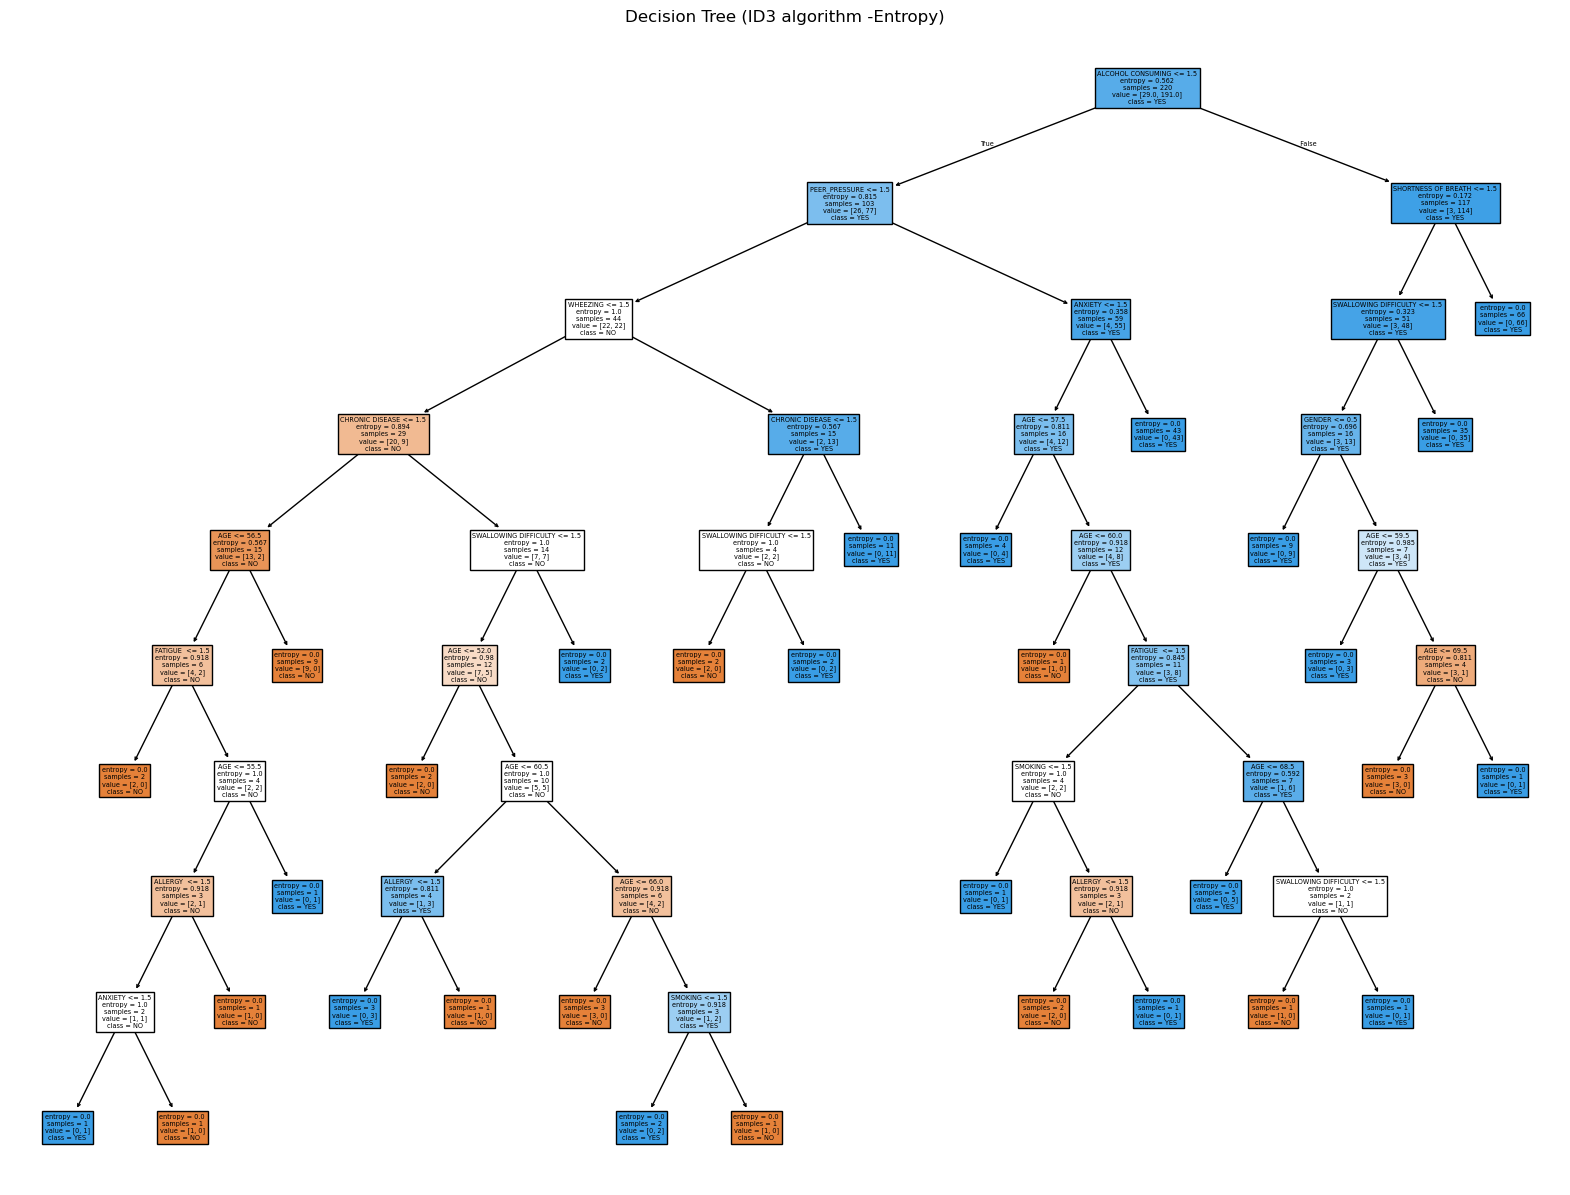

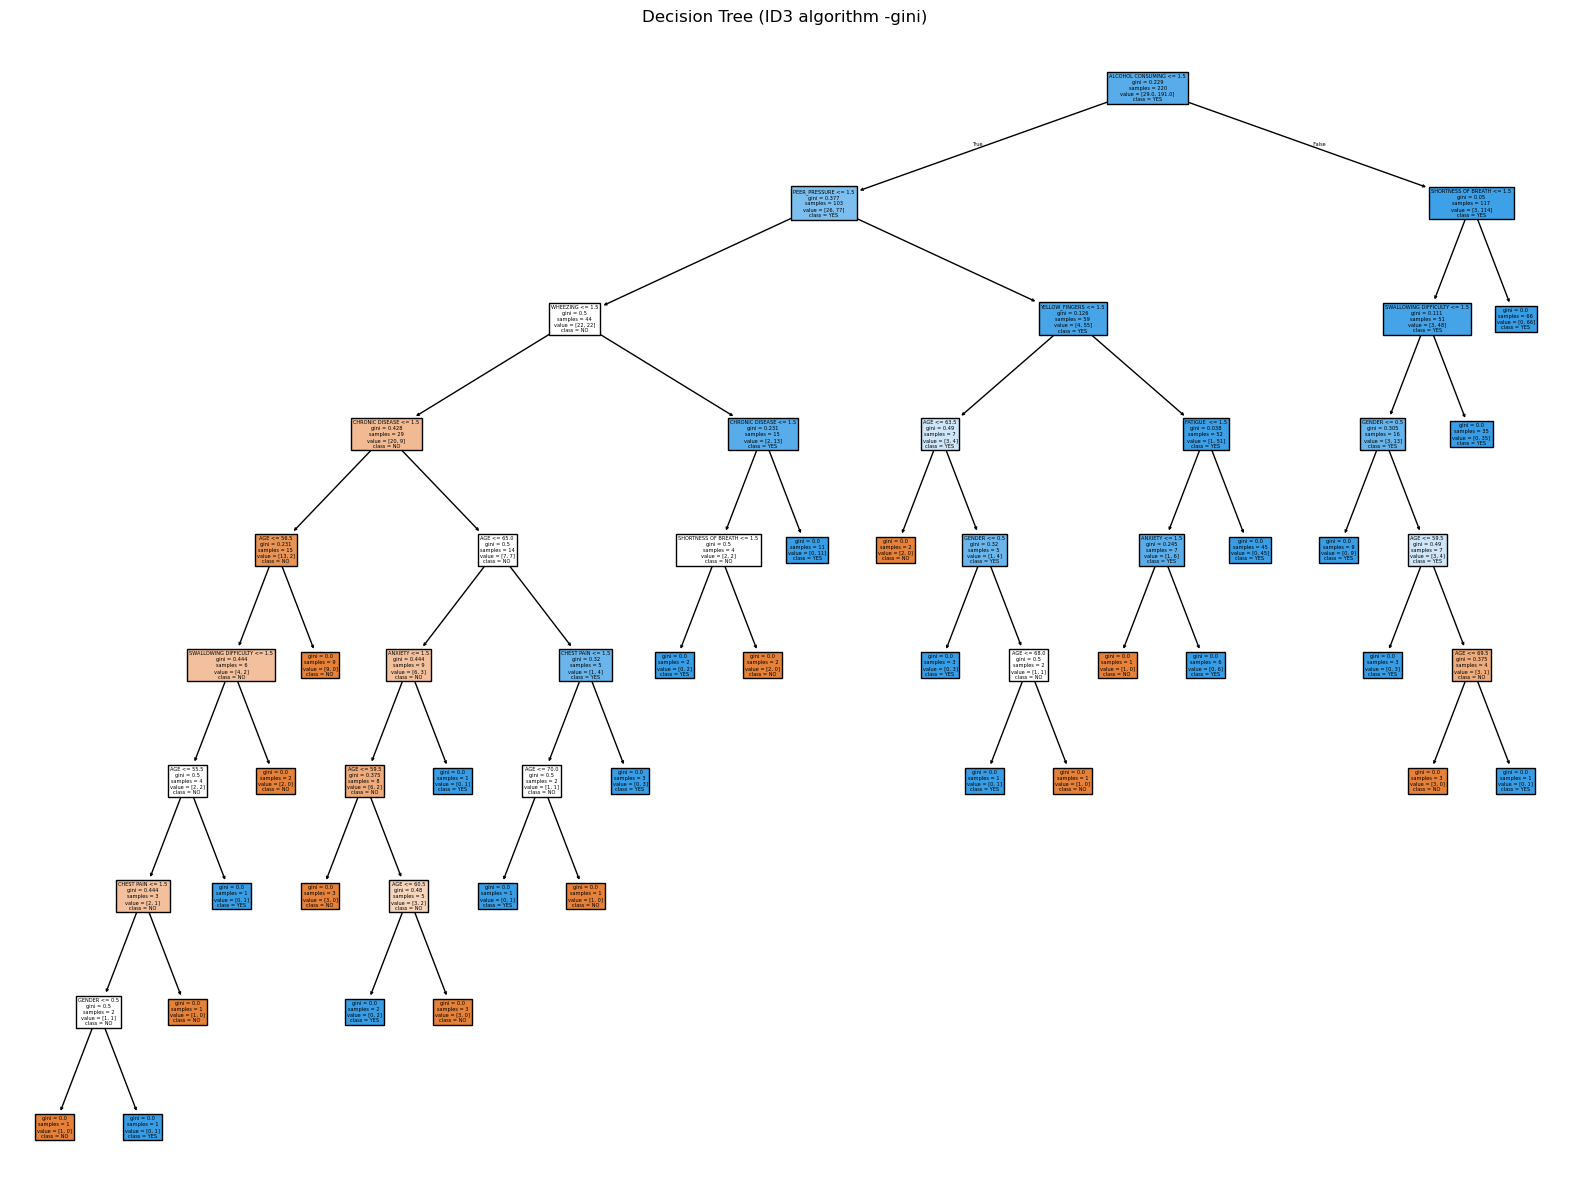

Prediction on new data:
['YES']


In [7]:

#Model selection and training

model_g=DecisionTreeClassifier(max_depth=9,criterion='gini')
model_e=DecisionTreeClassifier(max_depth=9,criterion='entropy')

#Model training
model_g.fit(X_train,Y_train)
model_e.fit(X_train,Y_train)

#prediction on test data
Y_pred_testg=model_g.predict(X_test)
Y_pred_teste=model_e.predict(X_test)

# Model Evaluation


print("\n--Decision Tree Results(With gini criterion)--")
print("Accuracy:", accuracy_score(Y_test, Y_pred_testg))
print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred_testg))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_testg))

print("\n--Decision Tree Results(With entropy criterion)--")
print("Accuracy:", accuracy_score(Y_test, Y_pred_teste))
print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred_teste))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred_teste))

#Visualizing the tree

plt.figure(figsize=(20,15))
plot_tree(model_e,
    feature_names=X.columns,
    class_names=le1.classes_,
    filled=True
)

plt.title("Decision Tree (ID3 algorithm -Entropy)")
plt.show()


#Visualizing the tree
plt.figure(figsize=(20,15))
plot_tree(model_g,
    feature_names=X.columns,
    class_names=le1.classes_,
    filled=True
)

plt.title("Decision Tree (ID3 algorithm -gini)")
plt.show()

#Prediction on new data

new_data=pd.DataFrame({
'GENDER':[1],
'AGE':[40],
'SMOKING':[2],
'YELLOW_FINGERS':[2],          
'ANXIETY':[1],               
'PEER_PRESSURE':[1],            
'CHRONIC DISEASE':[2],
'FATIGUE ':[1],
'ALLERGY ':[1],
'WHEEZING':[1],
'ALCOHOL CONSUMING':[2],
'COUGHING':[2],
'SHORTNESS OF BREATH':[1],
'SWALLOWING DIFFICULTY':[1],
'CHEST PAIN':[1]})
pred_new=model_e.predict(new_data)
print("Prediction on new data:")
print(le1.inverse_transform(pred_new))

### KNearest-Neighbour

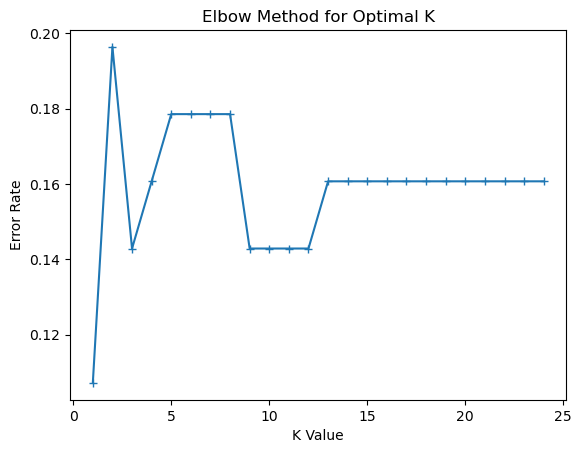

Model evaluation: 
Accuracy: 0.8571428571428571
Confusion Matrix:
 [[ 1  8]
 [ 0 47]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.11      0.20         9
           1       0.85      1.00      0.92        47

    accuracy                           0.86        56
   macro avg       0.93      0.56      0.56        56
weighted avg       0.88      0.86      0.81        56

Prediction on new data:
['YES']


In [9]:
# Elbow Method (Find Best K)

error_rate = []

for k in range(1, 25):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, Y_train)
    pred_k = model.predict(X_test)
    error_rate.append(np.mean(pred_k != Y_test))

# Plot Elbow Graph
plt.plot(range(1, 25), error_rate, marker='+')
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.title("Elbow Method for Optimal K")
plt.show()

# Model selection and training
model=KNeighborsClassifier(n_neighbors=11)

#Model training
model.fit(X_train,Y_train)

#Prediction
pred=model.predict(X_test)

#Model evaluation 
print("Model evaluation: ")
print("Accuracy:", accuracy_score(Y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(Y_test, pred))
print("\nClassification Report:\n", classification_report(Y_test, pred))

#Prediction on new data

new_data=pd.DataFrame({
'GENDER':[1],
'AGE':[40],
'SMOKING':[2],
'YELLOW_FINGERS':[2],          
'ANXIETY':[1],               
'PEER_PRESSURE':[1],            
'CHRONIC DISEASE':[2],
'FATIGUE ':[1],
'ALLERGY ':[1],
'WHEEZING':[1],
'ALCOHOL CONSUMING':[2],
'COUGHING':[2],
'SHORTNESS OF BREATH':[1],
'SWALLOWING DIFFICULTY':[1],
'CHEST PAIN':[1]})
pred_new=model.predict(new_data)
print("Prediction on new data:")
print(le1.inverse_transform(pred_new))

### Logistic_Regression

Accuracy of the model:  87.5
confusion matrix :
 [[ 3  6]
 [ 1 46]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.33      0.46         9
           1       0.88      0.98      0.93        47

    accuracy                           0.88        56
   macro avg       0.82      0.66      0.70        56
weighted avg       0.86      0.88      0.85        56



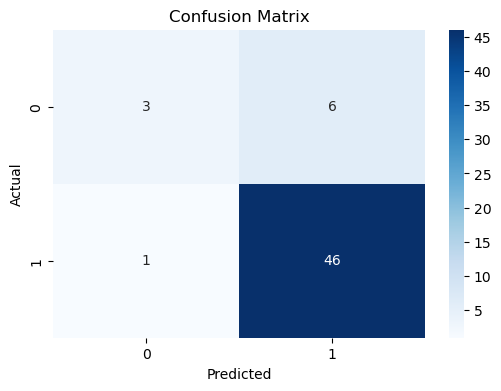

Prediction on new data:
['YES']


In [10]:
#Training the model
model=LogisticRegression(max_iter=1000)
model.fit(X_train,Y_train)

#prediction
Y_pred_train=model.predict(X_train)
Y_pred_test=model.predict(X_test)



#Model evaluation
acc = accuracy_score(Y_test, Y_pred_test)
cm = confusion_matrix(Y_test, Y_pred_test)


print("Accuracy of the model: ",round(acc*100,2))
print("confusion matrix :\n",cm)
print("Classification Report:\n", classification_report(Y_test, Y_pred_test))

#confusion matrix:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#plt.figure(figsize=(6,4))
#sns.heatmap(X.corr, annot=True, fmt='d', cmap='Greens')

#Prediction on new data

new_data=pd.DataFrame({
'GENDER':[1],
'AGE':[40],
'SMOKING':[2],
'YELLOW_FINGERS':[2],          
'ANXIETY':[1],               
'PEER_PRESSURE':[1],            
'CHRONIC DISEASE':[2],
'FATIGUE ':[1],
'ALLERGY ':[1],
'WHEEZING':[1],
'ALCOHOL CONSUMING':[2],
'COUGHING':[2],
'SHORTNESS OF BREATH':[1],
'SWALLOWING DIFFICULTY':[1],
'CHEST PAIN':[1]})
pred_new=model.predict(new_data)
print("Prediction on new data:")
print(le1.inverse_transform(pred_new))

### Naive Bayes

Model evaluation:
Accuracy: 
0.8571428571428571

confusion matrix
[[ 3  6]
 [ 2 45]]

 Classification report :
              precision    recall  f1-score   support

           0       0.60      0.33      0.43         9
           1       0.88      0.96      0.92        47

    accuracy                           0.86        56
   macro avg       0.74      0.65      0.67        56
weighted avg       0.84      0.86      0.84        56

0.8571428571428571


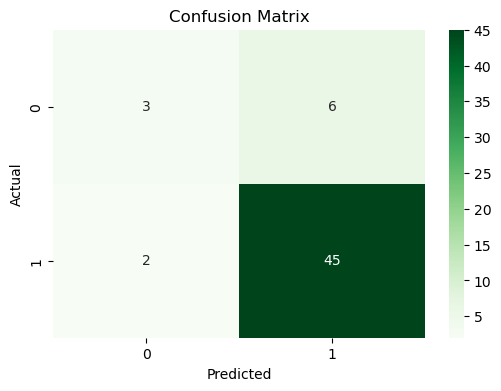

Prediction on new data:
['YES']


In [11]:

model=GaussianNB()
model.fit(X_train,Y_train)

#prediction
Y_pred_test=model.predict(X_test)

#Model evaluation
print("Model evaluation:")
print("Accuracy: ")
print(accuracy_score(Y_test,Y_pred_test))
print("\nconfusion matrix")
print(confusion_matrix(Y_test,Y_pred_test))
print("\n Classification report :")
print(classification_report(Y_test,Y_pred_test))
print(model.score(X_test,Y_test))

#Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred_test)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Prediction on new data

new_data=pd.DataFrame({
'GENDER':[1],
'AGE':[40],
'SMOKING':[2],
'YELLOW_FINGERS':[2],          
'ANXIETY':[1],               
'PEER_PRESSURE':[1],            
'CHRONIC DISEASE':[2],
'FATIGUE ':[1],
'ALLERGY ':[1],
'WHEEZING':[1],
'ALCOHOL CONSUMING':[2],
'COUGHING':[2],
'SHORTNESS OF BREATH':[1],
'SWALLOWING DIFFICULTY':[1],
'CHEST PAIN':[1]})
pred_new=model.predict(new_data)
print("Prediction on new data:")
print(le1.inverse_transform(pred_new))

### Support Vector Classifier

Model accuracy with different kernels:

Kernel: linear -- Accuracy: 0.8750
Kernel: poly -- Accuracy: 0.8393
Kernel: rbf -- Accuracy: 0.8393
Kernel: sigmoid -- Accuracy: 0.8393

Model evaluation:
Accuracy: 0.875

 Classification report :
              precision    recall  f1-score   support

           0       0.75      0.33      0.46         9
           1       0.88      0.98      0.93        47

    accuracy                           0.88        56
   macro avg       0.82      0.66      0.70        56
weighted avg       0.86      0.88      0.85        56

0.875


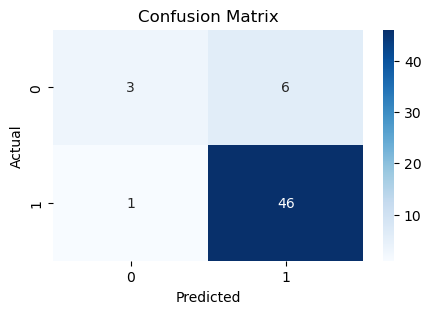

Prediction on new data:
['YES']


In [12]:
#Training the model
model_svm=SVC(gamma='scale',kernel='linear')
model_svm.fit(X_train,Y_train)

#prediction
Y_pred_test=model_svm.predict(X_test)



#Compare kernels
print("Model accuracy with different kernels:\n")
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, Y_train)
    acc = accuracy_score(Y_test, model.predict(X_test))
    print(f'Kernel: {k} -- Accuracy: {acc:.4f}')
    
#Model evaluation
print("\nModel evaluation:")
acc=accuracy_score(Y_test,Y_pred_test)
print("Accuracy:", acc)
print("\n Classification report :")
print(classification_report(Y_test,Y_pred_test))
print(model_svm.score(X_test,Y_test))

#Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred_test)
plt.figure(figsize=(5,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Prediction on new data

new_data=pd.DataFrame({
'GENDER':[1],
'AGE':[40],
'SMOKING':[2],
'YELLOW_FINGERS':[2],          
'ANXIETY':[1],               
'PEER_PRESSURE':[1],            
'CHRONIC DISEASE':[2],
'FATIGUE ':[1],
'ALLERGY ':[1],
'WHEEZING':[1],
'ALCOHOL CONSUMING':[2],
'COUGHING':[2],
'SHORTNESS OF BREATH':[1],
'SWALLOWING DIFFICULTY':[1],
'CHEST PAIN':[1]})
pred_new=model.predict(new_data)
print("Prediction on new data:")
print(le1.inverse_transform(pred_new))